<center>

# Analytical calculations for Incoherent test

#### Author: Daniel Lomholt Christensen

</center>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mcstasscript as ms
import os

#### Scattering from a thin incoherent sample

In [2]:
# First calculate the scattering from a thin sample
def n_measured_thin(flux, area, dist, rho, solid, cross, mu):
    return flux*area*rho*cross*dist*solid/4/np.pi*mu

In [3]:
# Calculated total scattered intensity, uncorrected for absorption
flux = 1e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 0.1 # Distance travelled by the neutron inside sample in cm
rho= 0.0723#1/13.827 # Unit cell density. AA^-3 (10^-24 cm)
cross=5.08 # Cross section in barns (10^-24 cm)
mu = 1 # Attenuation factor
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thin(flux, area, dist, rho, solid, cross, mu)
solid = 10/100**2# Solid angle in radians. A/r^2
n_solid =n_measured_thin(flux, area, dist, rho, solid, cross, mu)
print(f"Total scattering= {n_tot:.4g}n/s\nScattering at detector={n_solid:.4g}n/s")

Total scattering= 3.673e+05n/s
Scattering at detector=29.23n/s


In [4]:
# Calculated total scattered intensity, corrected for absorption
flux = 1e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 0.1 # Distance travelled by the neutron inside sample in cm
rho= 0.0723#1/13.827 # Unit cell density. AA^-3 (10^-30 m)
cross=5.08 # Cross section in barns (10^-24 cm^2)
wavelength = 1/np.sqrt(25.3)/0.11056

mu = (5.08 + 5.08*wavelength/1.7982)*rho # Attenuation factor in cm^-1
print("mu=",mu)
mu = np.exp(-mu*(dist + 0.003)) # Attenuation factor
print("att factor =",mu)
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thin(flux, area, dist, rho, solid, cross, mu)
solid = 10/99.95**2#10/100.00**2# Solid angle in radians. A/r^2. r is the average distance to the detector
n_solid =n_measured_thin(flux, area, dist, rho, solid, cross, mu)
print(f"Total scattering= {n_tot:.5g}n/s\nScattering at detector={n_solid:.4g}n/s")

mu= 0.7345711426890932
att factor = 0.9271306102621404
Total scattering= 3.4052e+05n/s
Scattering at detector=27.12n/s


### Finding the average distance travelled:



0.00103207433


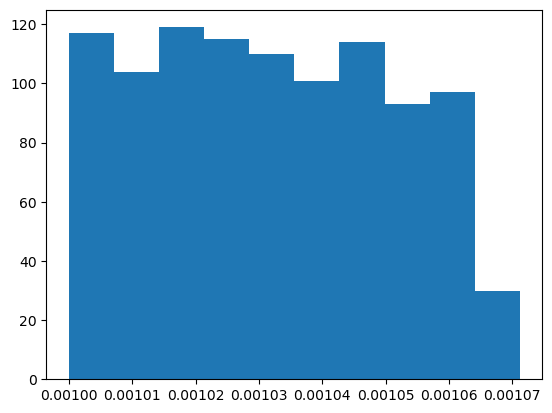

In [5]:
dists = [
0.00101474,0.00105192,0.00106183,0.00101038,0.00103997,0.00104117,0.00100654,0.00105218,0.00105128,0.00103878,0.0010348,0.00104127,0.00100965,0.00101808,0.0010123,0.0010388,0.00106522,0.00103079,0.0010502,0.00101952,0.00100992,0.0010169,0.00101047,0.00101521,0.0010101,0.00100348,0.00100212,0.00105788,0.00101071,0.00102477,0.00101852,0.00104881,0.00106073,0.00102434,0.00100616,0.00104862,0.00100951,0.00103472,0.0010173,0.00103883,0.00101997,0.00101549,0.00100751,0.00100735,0.00102374,0.00105697,0.00102576,0.00102081,0.00103552,0.00102705,0.00101466,0.00102186,0.00103381,0.00100969,0.00106191,0.00100971,0.00103722,0.00102521,0.0010502,0.00104428,0.00105809,0.00105987,0.00106737,0.00103398,0.00106568,0.00103686,0.00102525,0.00102939,0.00101977,0.00100429,0.0010118,0.00104743,0.00106471,0.00100506,0.00104743,0.0010466,0.00101616,0.0010183,0.00100511,0.00100872,0.00100661,0.00100354,0.0010594,0.00100279,0.00104347,0.00100811,0.00100674,0.00101616,0.00104831,0.00104816,0.00103265,0.00101507,0.00101669,0.00101741,0.00100631,0.00103541,0.00103671,0.00101086,0.00105369,0.00104653,0.00104593,0.00101195,0.00102746,0.00104018,0.00104179,0.00100788,0.00102389,0.00105301,0.0010493,0.0010262,0.00100797,0.00103337,0.00103302,0.00100649,0.00100163,0.00106104,0.00104047,0.00100175,0.00105997,0.00102689,0.00103567,0.00104143,0.00104009,0.00102667,0.001,0.00100192,0.00100691,0.00101298,0.00105536,0.00101265,0.00104587,0.00104292,0.00102609,0.00101445,0.001054,0.0010406,0.00102419,0.00106551,0.00104642,0.00104649,0.00101588,0.00101868,0.00102044,0.00102416,0.00103584,0.00100498,0.00102874,0.00103005,0.0010641,0.00103766,0.00102897,0.00105318,0.00104925,0.00101973,0.00104282,0.00104273,0.0010269,0.00106522,0.00100904,0.00100449,0.00102869,0.00106141,0.00104174,0.00101608,0.00104106,0.00104683,0.00103159,0.00103131,0.00102997,0.00100532,0.00101958,0.0010466,0.00106245,0.0010159,0.00104644,0.00104478,0.00102688,0.00101297,0.00103158,0.0010654,0.00106207,0.00103108,0.00101554,0.00102276,0.00100567,0.00101652,0.00100038,0.0010289,0.00101831,0.00104304,0.00100984,0.00102104,0.00101538,0.00101752,0.00104078,0.00101219,0.00104364,0.00103126,0.00101224,0.00104177,0.00104272,0.00102498,0.00101299,0.00102244,0.00106285,0.00101878,0.00105719,0.00103493,0.00100825,0.00106085,0.00100926,0.00106212,0.00100122,0.00102553,0.00101283,0.00104822,0.00105586,0.00106089,0.00105901,0.0010276,0.00100758,0.00100285,0.00104112,0.00102052,0.00102266,0.001009,0.00104136,0.00100191,0.0010228,0.00104973,0.00101511,0.00102446,0.00102809,0.0010594,0.00101732,0.00103946,0.00100389,0.00104225,0.00106586,0.00104585,0.00102898,0.00103933,0.00100963,0.00102244,0.00105797,0.00105433,0.00104452,0.00101246,0.00100432,0.00106036,0.00104986,0.00101786,0.00101009,0.00106109,0.00104398,0.0010382,0.00104754,0.00102182,0.00103438,0.00103146,0.00103774,0.00103688,0.00102287,0.00106069,0.00100743,0.00103325,0.00105713,0.00100634,0.00103522,0.00100003,0.00106254,0.00104255,0.00104556,0.00103824,0.0010021,0.0010005,0.00105545,0.0010245,0.00105377,0.00106223,0.00104606,0.00102529,0.00105599,0.00102435,0.0010451,0.00106264,0.00103858,0.00102239,0.00105951,0.00101601,0.00101065,0.00101562,0.0010385,0.00104427,0.00104616,0.00101338,0.00101665,0.00101886,0.00103845,0.00100286,0.00100804,0.0010388,0.00104052,0.00106339,0.00101432,0.00100691,0.0010327,0.00105533,0.00102808,0.00102387,0.00102758,0.00101957,0.00100917,0.0010357,0.00104393,0.00101405,0.00102631,0.00104333,0.00105143,0.00106096,0.00104708,0.00103002,0.00104427,0.00104974,0.00100312,0.00102919,0.00104507,0.00105069,0.00101427,0.00103158,0.00103193,0.00103122,0.00105899,0.00103886,0.00100577,0.00105812,0.00105424,0.00104169,0.00105459,0.00105165,0.00105698,0.00104008,0.00104609,0.00103191,0.00101819,0.00105861,0.00105181,0.00104206,0.00103101,0.00105357,0.0010483,0.00102203,0.00106973,0.00103954,0.00103439,0.0010416,0.001033,0.00103833,0.00105875,0.00104687,0.00100956,0.00106312,0.0010598,0.00106086,0.00102148,0.00100663,0.00105219,0.00102337,0.00102741,0.00102889,0.00100953,0.0010025,0.00102343,0.00101928,0.00100544,0.00106132,0.00106615,0.00103782,0.00104985,0.00102939,0.00106135,0.00106181,0.0010521,0.00101288,0.00102776,0.00106039,0.00100494,0.00101651,0.00101172,0.00100307,0.00100626,0.00105243,0.00103589,0.00101584,0.00105557,0.00104517,0.00101948,0.00101536,0.00106223,0.00102674,0.00106072,0.00105085,0.00103485,0.00101386,0.001044,0.00105049,0.00104278,0.00104177,0.00105334,0.00100678,0.00105949,0.00103055,0.00104515,0.00105719,0.00104715,0.00103491,0.0010513,0.00104631,0.00102192,0.00102352,0.00102833,0.00103857,0.00100697,0.00102518,0.00103061,0.00102116,0.00100354,0.00104928,0.00105833,0.00100827,0.00100452,0.00102862,0.00105696,0.00102086,0.00102093,0.00100457,0.00102492,0.00105083,0.00104563,0.00104943,0.00100291,0.00105913,0.00103608,0.00105207,0.00104345,0.00106211,0.00100142,0.0010573,0.00104865,0.00104413,0.00103319,0.00102219,0.00106236,0.00104952,0.00104337,0.00101378,0.00101589,0.00102051,0.00105548,0.00104721,0.00106226,0.00104005,0.00101286,0.00104573,0.00100685,0.00105122,0.00103936,0.00105736,0.00101658,0.0010342,0.00105671,0.00106514,0.00100445,0.00104539,0.00101989,0.00100985,0.00105134,0.00100005,0.00102846,0.00101008,0.00103095,0.00100473,0.00102276,0.00100389,0.00103803,0.00102328,0.00100251,0.0010006,0.00106074,0.00101567,0.00102503,0.00105838,0.00100508,0.00103129,0.00103496,0.00104448,0.00103265,0.00102473,0.00102798,0.00102218,0.00105941,0.00102407,0.00100094,0.00101787,0.00101546,0.00103407,0.00106638,0.00103195,0.00104388,0.00102087,0.00104341,0.00104016,0.00103833,0.00100239,0.0010399,0.00102273,0.00102219,0.0010631,0.00105389,0.00103679,0.00100596,0.00105556,0.00106061,0.00105612,0.00102974,0.00104845,0.00100178,0.00100262,0.00103871,0.00100712,0.00104862,0.00100574,0.00105175,0.00103108,0.00105714,0.00103962,0.00101026,0.00102286,0.0010456,0.00105046,0.00105568,0.00103586,0.00101559,0.00101071,0.00101997,0.00102236,0.00100386,0.00106804,0.00104772,0.0010239,0.00105808,0.00104604,0.00104833,0.00102019,0.00102593,0.00103111,0.0010265,0.00100348,0.00102636,0.00101329,0.00104729,0.00100144,0.00106462,0.00101782,0.00107118,0.00100722,0.00102992,0.00104377,0.00104522,0.00106813,0.00105086,0.00103078,0.00100971,0.00100308,0.00105376,0.00104867,0.0010241,0.00104343,0.00106205,0.00104268,0.00100555,0.00104144,0.00101171,0.00102211,0.00100001,0.00100659,0.00103471,0.00102621,0.001011,0.00105121,0.00105307,0.00103658,0.0010157,0.00102896,0.00101973,0.00102088,0.00100557,0.00106217,0.00103957,0.00101395,0.0010213,0.00103948,0.00102859,0.00102573,0.00103269,0.00100264,0.00102625,0.00100286,0.00102753,0.00103131,0.0010557,0.00103361,0.00101646,0.00104903,0.00100427,0.00102396,0.0010441,0.00103466,0.00105921,0.00102773,0.00106477,0.00100973,0.00103504,0.00102723,0.00100453,0.00102881,0.00100404,0.00100411,0.00105669,0.00101722,0.00105444,0.00104165,0.00103533,0.00100319,0.00102009,0.00103136,0.00101915,0.00100728,0.00102792,0.00100501,0.00100401,0.00105023,0.00105949,0.001046,0.00102619,0.00102633,0.00103604,0.00103903,0.00103795,0.00106613,0.00100829,0.00104476,0.001037,0.00103283,0.00103666,0.00101699,0.00101869,0.00101215,0.00106248,0.00102112,0.00100317,0.00104612,0.00102569,0.0010495,0.00101895,0.00103595,0.0010544,0.0010519,0.00105771,0.00106295,0.00101521,0.0010227,0.00106045,0.00100202,0.00101781,0.00101909,0.00101673,0.00101781,0.00105649,0.00106039,0.00105685,0.00103491,0.00102328,0.00102043,0.0010394,0.00102689,0.0010168,0.00102501,0.00103376,0.00102204,0.0010096,0.00105007,0.00105942,0.00102369,0.00101556,0.00100736,0.00100212,0.00101962,0.00100101,0.0010141,0.00104118,0.00104998,0.00104862,0.00103317,0.00105507,0.00104436,0.00103484,0.00101069,0.00101932,0.00102031,0.00100106,0.00106618,0.00102926,0.00106323,0.00102085,0.00106444,0.00103278,0.00102471,0.0010175,0.00104195,0.00100074,0.00103916,0.0010518,0.00104036,0.00105908,0.00104996,0.001045,0.00100542,0.00104336,0.00106109,0.00105169,0.00102042,0.00101838,0.00105196,0.00105052,0.00100457,0.0010201,0.00103817,0.00104703,0.00106579,0.00101813,0.00100914,0.00101022,0.00102048,0.00103621,0.00104381,0.00100928,0.00100279,0.00100176,0.00100922,0.00102299,0.00101014,0.00101832,0.00100785,0.00106106,0.00103955,0.00105784,0.001056,0.00102575,0.00106482,0.00103451,0.00103733,0.00101938,0.00101552,0.00105661,0.00105992,0.00104262,0.00103284,0.00101761,0.00100705,0.00103856,0.00106534,0.0010568,0.0010509,0.00102712,0.0010122,0.00102764,0.00105137,0.001007,0.00101421,0.00100397,0.00102396,0.00106113,0.00106064,0.00101731,0.00100819,0.00102174,0.00104734,0.00101522,0.00100196,0.00104523,0.00104662,0.00106249,0.00103012,0.00104134,0.00100906,0.00100505,0.00103555,0.00100598,0.00103198,0.00100758,0.00101791,0.00104744,0.00103241,0.00103461,0.00103802,0.00103344,0.00101009,0.0010488,0.001033,0.00106211,0.00106878,0.00102311,0.00103501,0.00105594,0.0010349,0.00104824,0.00100537,0.00102879,0.00104831,0.00105876,0.00100974,0.00105368,0.00100301,0.00106166,0.00101319,0.00104386,0.00101546,0.00101161,0.00101941,0.00102034,0.00106449,0.00104295,0.00102158,0.00105184,0.00102796,0.00101069,0.00101294,0.00101615,0.0010609,0.00105214,0.00105057,0.00103476,0.00103718,0.0010485,0.00102952,0.00101867,0.00105946,0.00100406,0.00102665,0.0010513,0.00103065,0.00103813,0.00105035,0.00100522,0.00106275,0.0010278,0.00104663,0.00105723,0.00100503,0.00106051,0.00104702,0.00104714,0.00101289,0.00103975,0.00105927,0.00101204,0.00104147,0.00101081,0.00101275,0.00100588,0.00104181,0.00104895,0.00103526,0.00104112,0.00100792,0.00101178,0.00102248,0.0010127,0.0010486,0.00106259,0.00102984,0.00105252,0.00105633,0.00101789,0.00101963,0.00105449,0.0010059,0.00100747,0.00101064,0.00101027,0.00106705,0.00102851,0.00101377,0.00100546,0.00100926,0.00101156,0.00103612,0.0010314,0.00105193,0.00105176,0.00104268,0.00104432,0.00106704,0.00102888,0.00100413,0.00105247,0.00104718,0.00100335,0.00100023,0.00101705,0.0010486,0.00103013,0.00103696,0.00103079,0.00102465,0.00102058,0.00100262,0.0010004,0.00101203,0.00100598,0.0010226,0.00103111,0.001028,0.00105069,0.00100765,0.00104984,0.00102472,0.00101801,0.00100661,0.00104384,0.00105339,0.00102827,0.00101468,0.00106165,0.00105455,0.00101005,0.001024,0.00100141,0.00101253,0.00105705,0.0010484,0.00106394,0.00105264,0.00104611,0.00103431,0.00103262,0.00105371,0.00106761,0.00101747,0.00101425,0.00104087,0.00105234,0.00102425,0.00104563,0.00105307,0.00103945,0.00106318,0.00105346,0.00100488,0.00103075,0.00103415,0.00104849,0.00102495,0.00102914,0.00104749,0.00102658,0.0010281,0.00101303,0.00103996,0.00103838,0.00103443,0.00100625,0.00103259,0.00101516,0.00106058,0.0010365,0.00102514,0.00101928,0.00104138,0.00103255,0.00103658,0.00102382,0.00106243,0.00103265,0.00101895,0.00100676,0.0010198,0.00100289,0.00102256,0.00102328,0.0010527,0.0010142,0.00102435,0.00103485,0.00100562,0.00104553,0.00106897,0.00102277,0.00103307    ]

plt.hist(dists)
print(np.average(dists))

#### Backscattering from a thick incoherent sample

In [6]:
# If there is data, load it in
path = "../data/inc_box_thick/"
if os.path.exists(path):
    data_X = []
    data_I = []
    data_E = []
    for file in os.listdir(path):
        if "." in file:
            continue
        sim = ms.load_data(path+file)
        data_X.append(sim[2].metadata.parameters['thick'])
        data_I.append(sim[2].metadata.total_I)
        data_E.append(sim[2].metadata.total_E)
data = np.array([data_X, data_I, data_E])

In [7]:
def n_measured_thick(flux, area, dist, rho, solid, cross, mu):
    l_app = (1-np.exp(-2*mu*dist))/2/mu
    solid = 10/(100+l_app)**2
    result = flux*area*rho*cross*solid/4/np.pi *l_app

    return result
# Calculated total scattered intensity, uncorrected for absorption
flux = 0.9999e7 # incoming flux 25 mm from sample n/s/cm^2
area = 1 # square cm
dist = 0.1 # Distance travelled by the neutron inside sample in cm
rho= 1/13.827 # Unit cell density. AA^-3 (10^-24 cm)
cross=5.08 # Cross section in barns (10^-24 cm)
speed = np.sqrt(10)*437.39

mu = (5.08 + 5.08*2200/speed)*rho # Attenuation factor in cm^-1
print(mu)
# mu = 0.96
solid = 4*np.pi# Solid angle in radians. A/r^2
n_tot = n_measured_thick(flux, area, dist, rho, solid, cross, mu)
solid = 10/100**2# Solid angle in radians. A/r^2
solid = 10/100**2# Solid angle in radians. A/r^2
n_solid =n_measured_thick(flux, area, dist, rho, solid, cross, mu)
# Now simulate for many thicknesses what their scattering is
dist = np.linspace(0.1,5,1000)
absolute_scattering = n_measured_thick(flux, area, dist, rho, solid, cross, mu)
#print(f"Total scattering= {n_tot:.4g}n/s\nScattering at detector={n_solid:.4g}n/s")

0.9517693664623029


In [8]:
0.031622776602**2

0.0010000000000199986

In [10]:
print(data[1])

[151.266  151.936  151.726  152.428  149.193  148.127  151.038  129.766
  26.5944 137.125  119.442  151.267  146.331  151.919  151.747  112.446
 151.204  147.048   48.538  133.602  148.441  151.251  124.991  149.683
 151.701  151.981  151.671  151.404  151.697  151.448  152.055  152.265
 151.766  152.338  152.047  150.705  150.642   93.8028 144.824   81.5977
 139.129  152.465  152.02   152.303   66.6906 141.445  103.93   143.224
 150.014  151.102 ]


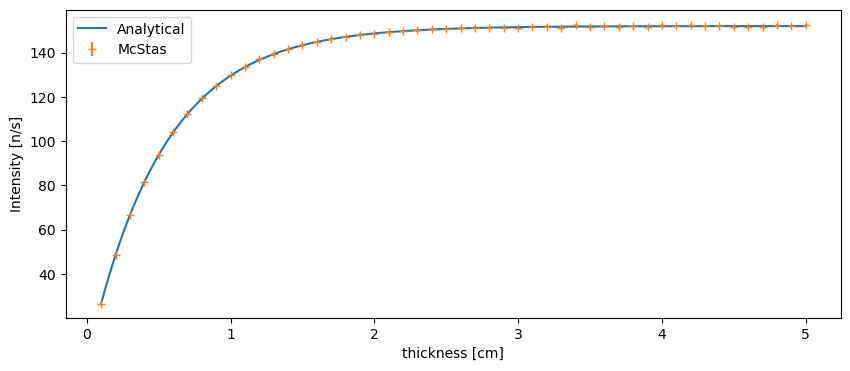

In [9]:

fig, ax = plt.subplots(ncols=1, figsize=(10,4))
ax.plot(dist, absolute_scattering, '-', label="Analytical")
ax.errorbar(data[0]*100,data[1],data[2], fmt='+', label="McStas")
# ax[1].plot(100*data[0],
#            100*(1-data[1]/ n_measured_thick(flux, area, data[0]*100, rho, solid, cross, mu)),
#            ".", label="Difference")
ax.set(xlabel="thickness [cm]", ylabel="Intensity [n/s]")
ax.legend()
#ax[1].set(xlabel="thickness [cm]", ylabel="Difference [%]")